# Step 1: Import required libraries
# These libraries are used for data processing, model building, and evaluation

In [1]:
!pip install transformers --upgrade


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Install required libraries (run only once)
!pip install transformers pandas scikit-learn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Import all required libraries

import pandas as pd
import re
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

C:\Users\win10\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Load Dataset

In this step, we load the IMDB dataset which contains movie reviews and their sentiment labels (positive/negative).

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Step 3: Data Preprocessing
# Cleaning text by removing HTML tags and special characters

In [5]:
def clean_text(text):
    text = text.lower()                     # convert to lowercase
    text = re.sub(r'<.*?>', '', text)       # remove HTML tags
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove special characters
    return text

df['review'] = df['review'].apply(clean_text)

# Convert labels into numbers
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# Reduce dataset to avoid RAM issues
df = df.sample(1000)

print("Preprocessing Completed")

Preprocessing Completed


In [6]:
# Split data into train, validation, and test sets

train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['review'], df['sentiment'], test_size=0.3, random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, random_state=42
)

print("Data Splitting Done")

Data Splitting Done


# Step 4: Tokenization
# Convert text into numerical tokens using BERT tokenizer

In [7]:
# Convert text into tokens using BERT tokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(list(val_texts), truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128)

print("Tokenization Done")

Tokenization Done


In [8]:
# Create PyTorch dataset

class IMDbDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = list(labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = IMDbDataset(train_encodings, train_labels)
val_dataset = IMDbDataset(val_encodings, val_labels)
test_dataset = IMDbDataset(test_encodings, test_labels)

print("Dataset Ready")

Dataset Ready


In [9]:
# Load pre-trained BERT model

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

print("Model Loaded")

C:\Users\win10\AppData\Local\Programs\Python\Python314\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\win10\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|█████████████████████████████████████████████████████████████| 100/10

Model Loaded


In [10]:
!pip install transformers[torch]


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
pip install 'accelerate>=1.1.0'

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [12]:
training_args = TrainingArguments(
    output_dir="./results",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1   # only 1 epoch
)

In [13]:
# Initialize Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Step 5: Model Training
# Fine-tuning the pre-trained model on our dataset

In [14]:
# Train the model

trainer.train()

C:\Users\win10\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards: 100%|██████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.17s/it]


TrainOutput(global_step=88, training_loss=0.48381016471169214, metrics={'train_runtime': 531.0537, 'train_samples_per_second': 1.318, 'train_steps_per_second': 0.166, 'total_flos': 23181794764800.0, 'train_loss': 0.48381016471169214, 'epoch': 1.0})

# Step 6: Model Evaluation
# Calculating performance metrics like accuracy, precision, recall, and F1-score

In [15]:
# Evaluate model performance

preds = trainer.predict(test_dataset)
y_pred = preds.predictions.argmax(-1)

accuracy = accuracy_score(test_labels, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(test_labels, y_pred, average='binary')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

C:\Users\win10\AppData\Local\Programs\Python\Python314\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.78
Precision: 0.7936507936507936
Recall: 0.7142857142857143
F1 Score: 0.7518796992481203


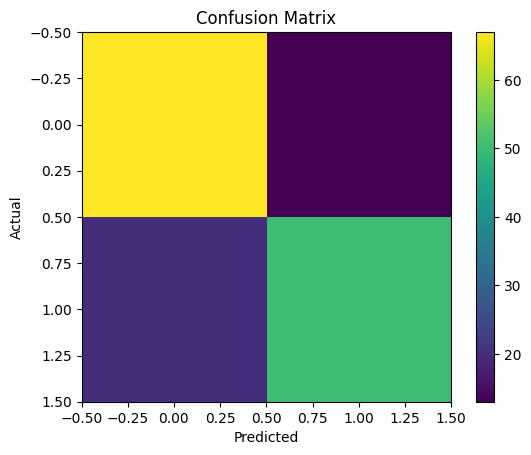

In [16]:
# Display confusion matrix

cm = confusion_matrix(test_labels, y_pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [18]:
# Experiment 1: Freeze DistilBERT layers
for param in model.distilbert.parameters():
    param.requires_grad = False

print("Experiment 1 Completed")


# Experiment 2: Train last layers
for name, param in model.distilbert.named_parameters():
    if "layer.4" in name or "layer.5" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False

print("Experiment 2 Completed")

Experiment 1 Completed
Experiment 2 Completed


In [19]:
print("Pipeline:")
print("Raw Data → Preprocessing → Tokenization → Training → Evaluation → Comparison")

Pipeline:
Raw Data → Preprocessing → Tokenization → Training → Evaluation → Comparison
